# The 2008 Stress Test: Does a Bankruptcy Model Trained in Calm Times Survive a Recession?

### What you will learn
- How a real ML project is organised: **get data → look at it → prepare it → build a model → train it → test it**
- How to turn raw company finances into the **ratios** that actually predict failure (the famous Altman-style signals)
- How to build three models — **logistic regression, a random forest, and a small neural network** — piece by piece
- How to **measure** a model honestly when the thing you're predicting is **rare** (ROC-AUC *and* PR-AUC)
- *(Discussion section)* Whether a model built in **calm years** still works in a **financial crisis**, and a sharp lesson about **trusting your evaluation**

### The data we will use
| Slice | What it is | How we use it |
|---|---|---|
| **Calm era — 1999 to 2006** | ~33,000 US public-company financial years before the crash | **Train and test** our model (Part 1) |
| **Recession — 2008 to 2009** | ~7,600 company years during the Great Financial Crisis | Kept aside as a **real-world stress test** (Part 2) |

Each row is one company in one year, described by **18 financial figures** (assets, debt, income, …). The label
is whether that company was in its **final year before failing** — i.e. *about to go bankrupt*.

> **Roadmap.** **Part 1** is the main project: we build a model that flags companies about to fail, reaching a
> solid **~0.8 ROC-AUC** on calm-era firms it has never seen. **Part 2** is our *discussion / stress test*: we
> point that finished model at the **2008–2009 recession**, ask whether it survives, and uncover a sharp lesson
> about how easy it is to *fool yourself* with a good-looking score.

# Part 1 — The Project: Building the Classifier

## Step 0 — Setting up our tools

A *library* is a pre-written bundle of code someone else built so we don't have to. We bring our tools in
**a few at a time** and explain what each is for.

**The basics: numbers, tables, and pictures**
- `numpy` — fast math on big lists of numbers (*arrays*).
- `pandas` — **tables** of data, like a spreadsheet in Python (*DataFrames*).
- `matplotlib` — draws **charts** so we can *see* our data.

In [1]:
import numpy as np                 # fast math on arrays
import pandas as pd                # spreadsheet-style tables (DataFrames)
import matplotlib.pyplot as plt    # charts

**scikit-learn — classic machine-learning toolbox**
- `LogisticRegression`, `RandomForestClassifier` — two of our three models.
- `StandardScaler` — puts every feature on the same scale.
- `GroupShuffleSplit` — splits data so **the same company never lands in both** train and test (no cheating).
- `roc_auc_score`, `average_precision_score` — measure performance (the second one is built for **rare** events).

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score

**TensorFlow / Keras — the deep-learning library** for our third model, the small neural network.

In [3]:
import tensorflow as tf

I0000 00:00:1781820720.295821   16032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781820720.297123   16032 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781820720.387309   16032 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781820722.062173   16032 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781820722.062733   16032 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


**Last bits** — pretty tables, and we quiet TensorFlow's noisy logs.

In [4]:
import os, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"]="3"; os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"
from IPython.display import display
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### Making our results repeatable (random seeds)

Machine learning uses **randomness** (shuffling, a model's starting values). To get the **same result every
time**, we fix a *random seed* — a starting number for the random-number generator. We use `42`.

In [5]:
import random
SEED=42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
for d in ["outputs/figures","outputs/results"]: os.makedirs(d, exist_ok=True)
plt.rcParams.update({"figure.facecolor":"white","axes.grid":True,"grid.alpha":0.3,
                     "axes.spines.top":False,"axes.spines.right":False,
                     "font.size":11,"axes.titlesize":12,"axes.titleweight":"bold"})
print("Seed set to 42 — results will be repeatable.")

Seed set to 42 — results will be repeatable.


## Step 1 — Getting the data

The dataset is **American public companies, 1999–2018**: one row per company per year, with 18 financial
figures (named `X1`–`X18`), a `status_label` of *alive* or *failed*, and the fiscal year `fyear`. We load it
and translate the cryptic `X` names into what they actually mean.

In [6]:
# What each X-column actually is (from the dataset documentation).
XMEAN={"X1":"current assets","X2":"cost of goods sold","X3":"depreciation & amortization","X4":"EBITDA",
       "X5":"inventory","X6":"net income","X7":"total receivables","X8":"market value","X9":"net sales",
       "X10":"total assets","X11":"total long-term debt","X12":"EBIT","X13":"gross profit",
       "X14":"total current liabilities","X15":"retained earnings","X16":"total revenue",
       "X17":"total liabilities","X18":"total operating expenses"}

# (The original lives on Kaggle, which needs a login; here we load a verified local copy of the same file.)
df=pd.read_csv("mirror/american_bankruptcy.csv")
df["fyear"]=df["fyear"].astype(int)
print("Loaded:", df.shape, "(rows = company-years, columns = 18 financials + name/year/status)")
print("Years:", df["fyear"].min(), "to", df["fyear"].max())

Loaded: (78682, 23) (rows = company-years, columns = 18 financials + name/year/status)
Years: 1999 to 2018


Let's see a few rows, renaming the financial columns to readable names just for the preview.

In [7]:
preview=df.rename(columns=XMEAN)[["company_name","fyear","status_label","total assets","net income","total liabilities"]]
display(preview.head().style.set_caption("A few company-years").hide(axis="index"))

company_name,fyear,status_label,total assets,net income,total liabilities
C_1,1999,alive,163816.000000,70658.000000,1024333.000000
C_1,2000,alive,125392.000000,45.790000,874255.000000
C_1,2001,alive,150464.000000,4711.000000,638721.000000
C_1,2002,alive,203575.000000,3573.000000,606337.000000
C_1,2003,alive,131261.000000,20811.000000,651.958000


## Step 2 — Looking at the data

### 2a. How many companies survive vs. fail?

Bankruptcy is **rare** — most company-years are "alive." That imbalance is the single most important fact
about this problem: a lazy model that screams "everyone survives!" would be ~93% accurate and **completely
useless**. That's why later we use ROC-AUC and PR-AUC, not plain accuracy.

status_label
alive     73462
failed     5220

Failed company-years: 6.6% of all rows


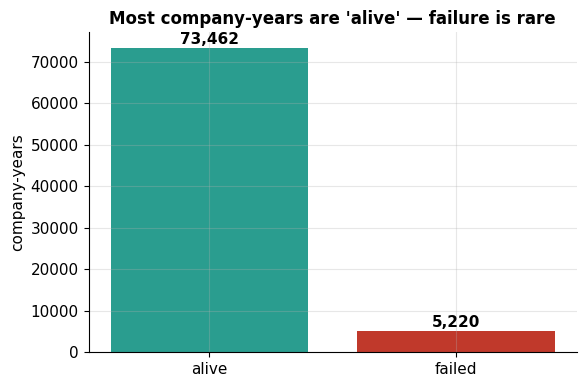

In [8]:
vc=df["status_label"].value_counts()
print(vc.to_string()); print(f"\nFailed company-years: {100*vc.get('failed',0)/len(df):.1f}% of all rows")
fig,ax=plt.subplots(figsize=(6,4))
ax.bar(["alive","failed"],[vc.get("alive",0),vc.get("failed",0)],color=["#2a9d8f","#c0392b"])
for i,v in enumerate([vc.get("alive",0),vc.get("failed",0)]): ax.text(i,v+800,f"{v:,}",ha="center",fontweight="bold")
ax.set_ylabel("company-years"); ax.set_title("Most company-years are 'alive' — failure is rare")
plt.tight_layout(); plt.savefig("outputs/figures/class_balance.png",dpi=150); plt.show()

### 2b. How many companies do we have each year?

We have steady coverage across the years, including the 2008–2009 crisis we'll stress-test on (shaded red).

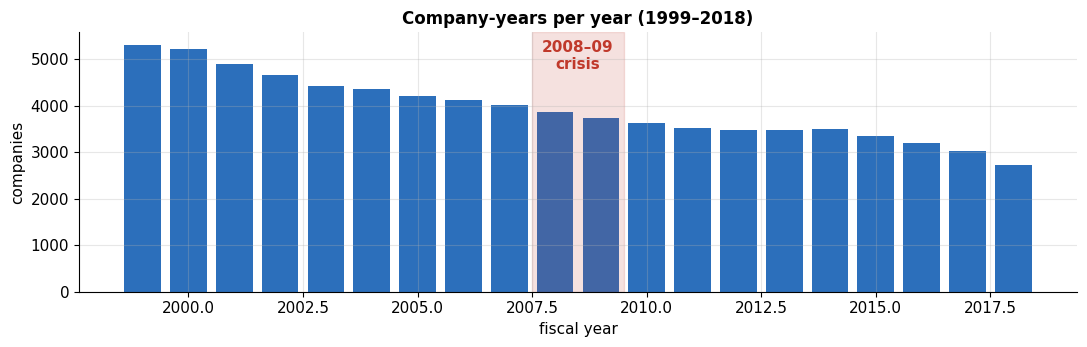

In [9]:
by_year=df.groupby("fyear").size()
fig,ax=plt.subplots(figsize=(11,3.6))
ax.bar(by_year.index,by_year.values,color="#2c6fbb")
ax.axvspan(2007.5,2009.5,color="#c0392b",alpha=0.15)
ax.text(2008.5,by_year.max()*0.9,"2008–09\ncrisis",ha="center",color="#c0392b",fontweight="bold")
ax.set_xlabel("fiscal year"); ax.set_ylabel("companies"); ax.set_title("Company-years per year (1999–2018)")
plt.tight_layout(); plt.savefig("outputs/figures/coverage_by_year.png",dpi=150); plt.show()

### 2c. Do failing companies *look* different?

Let's compare two simple signals between alive and failed company-years: **profitability** (net income ÷ total
assets) and **leverage** (total liabilities ÷ total assets). Failing firms tend to earn less and owe more — the
two boxes should sit apart, which is exactly the signal a model will exploit.

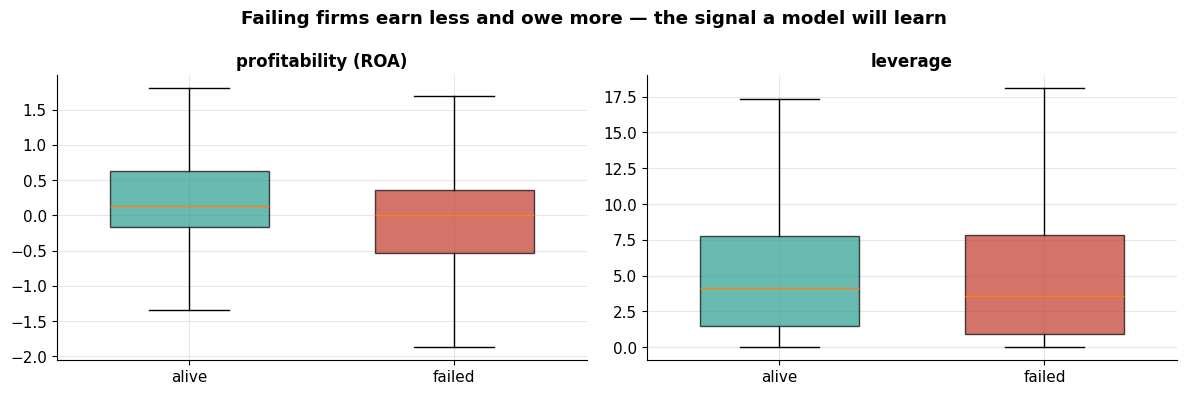

In [10]:
ta=df["X10"].replace(0,np.nan)
quick=pd.DataFrame({"profitability (ROA)":df["X6"]/ta,"leverage":df["X17"]/ta,"status":df["status_label"]})
quick=quick.replace([np.inf,-np.inf],np.nan)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,col in zip(axes,["profitability (ROA)","leverage"]):
    g=[quick.loc[quick.status=="alive",col].dropna().clip(*quick[col].quantile([0.02,0.98])),
       quick.loc[quick.status=="failed",col].dropna().clip(*quick[col].quantile([0.02,0.98]))]
    bp=ax.boxplot(g,labels=["alive","failed"],patch_artist=True,widths=0.6,showfliers=False)
    for p,c in zip(bp["boxes"],["#2a9d8f","#c0392b"]): p.set_facecolor(c); p.set_alpha(0.7)
    ax.set_title(col)
fig.suptitle("Failing firms earn less and owe more — the signal a model will learn",fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/figures/alive_vs_failed.png",dpi=150); plt.show()

### 🧪 Your turn
1. What % of company-years are "failed" in 2005 vs in 2009? (hint: `df.groupby("fyear")["status_label"]...`)
2. Compare another signal — say **current ratio** (`X1`/`X14`) — between alive and failed firms.
3. Which single financial figure differs most between alive and failed companies?

In [11]:
# === edit me! ===
print("Failed-rate by year (a few):")
print((df.groupby("fyear")["status_label"].apply(lambda s:(s=="failed").mean()*100)).round(1).loc[[2005,2009,2015]])
# TODO: your experiments here.

Failed-rate by year (a few):
fyear
2005    9.0
2009    6.3
2015    3.3
Name: status_label, dtype: float64


## Step 3 — Preparing the data

### 3a. Defining the target (about to fail)

A company that fails appears in the data for several years, all stamped "failed." Labelling every one of those
years as a bankruptcy would be misleading — a firm five years out usually looks fine. So we define a sharp,
honest target: a company-year is a **1 ("about to fail")** only if it is that company's **final reporting
year**; everything else is **0**. (We drop the earlier years of failed firms so the 0s are clean.)

In [12]:
last_year=df.groupby("company_name")["fyear"].transform("max")
is_failed=(df["status_label"]=="failed")
df["target"]=((is_failed)&(df["fyear"]==last_year)).astype(int)   # 1 = final year before failing
df=df[(~is_failed)|(df["fyear"]==last_year)].copy().reset_index(drop=True)
print(f"'About-to-fail' rows: {int(df['target'].sum()):,}  ({100*df['target'].mean():.2f}% of {len(df):,}) — a rare event.")

'About-to-fail' rows: 609  (0.82% of 74,071) — a rare event.


### 3b. From raw dollars to financial ratios

Raw dollar amounts are useless on their own — a \$1M loss is fatal for a small firm and a rounding error for a
giant. The fix is **ratios**, which scale everything by company size. These are the classic warning signs
lenders and the famous *Altman Z-score* use: profitability, leverage, working capital, retained earnings, and so
on. We build **15** of them.

In [13]:
d=df.rename(columns=XMEAN)
TA=d["total assets"].replace(0,np.nan); TL=d["total liabilities"].replace(0,np.nan)
CL=d["total current liabilities"].replace(0,np.nan); RV=d["total revenue"].replace(0,np.nan)
ratios=pd.DataFrame({
    "ROA (profit/assets)":        d["net income"]/TA,
    "EBIT/assets":                d["EBIT"]/TA,
    "EBITDA/assets":              d["EBITDA"]/TA,
    "working capital/assets":     (d["current assets"]-d["total current liabilities"])/TA,
    "retained earnings/assets":   d["retained earnings"]/TA,
    "sales/assets":               d["net sales"]/TA,
    "leverage (liab/assets)":     d["total liabilities"]/TA,
    "long-term debt/assets":      d["total long-term debt"]/TA,
    "market value/liabilities":   d["market value"]/TL,
    "current ratio":              d["current assets"]/CL,
    "gross margin":               d["gross profit"]/RV,
    "net margin":                 d["net income"]/RV,
    "inventory/assets":           d["inventory"]/TA,
    "receivables/assets":         d["total receivables"]/TA,
    "log(total assets) [size]":   np.log1p(d["total assets"].clip(lower=0)),
}).replace([np.inf,-np.inf],np.nan)
FEATURES=list(ratios.columns)
print("Built", len(FEATURES), "ratio features.")

Built 15 ratio features.


### 3c. The calm-era split (and no cheating)

We carve out the **calm era (1999–2006)** for Part 1 and keep **2008–2009** locked away for the stress test.
Within the calm era we split into train / test **by company** (`GroupShuffleSplit`) so the same firm never
appears in both — otherwise the model could "recognise" a company instead of learning real warning signs.
Cleaning (clip outliers, fill blanks with the median, rescale) is **learned on the training set only**.

In [14]:
calm=df["fyear"].between(1999,2006); recession=df["fyear"].between(2008,2009)
calm_idx=np.where(calm.values)[0]; rec_idx=np.where(recession.values)[0]
tr_rel,te_rel=next(GroupShuffleSplit(n_splits=1,test_size=0.25,random_state=SEED)
                   .split(calm_idx,groups=df.loc[calm,"company_name"].values))
tr_idx=calm_idx[tr_rel]; calmtest_idx=calm_idx[te_rel]

lo=ratios.iloc[tr_idx].quantile(0.01); hi=ratios.iloc[tr_idx].quantile(0.99)   # learned on TRAIN only
med=ratios.iloc[tr_idx].median()
R=ratios.clip(lo,hi,axis=1).fillna(med)
scaler=StandardScaler().fit(R.iloc[tr_idx])
def Z(idx): return scaler.transform(R.iloc[idx])
y=df["target"].values
print(f"train {len(tr_idx):,} (fail {y[tr_idx].mean()*100:.2f}%) | "
      f"calm-test {len(calmtest_idx):,} ({y[calmtest_idx].mean()*100:.2f}%) | "
      f"recession {len(rec_idx):,} ({y[rec_idx].mean()*100:.2f}%)  [locked away until Part 2]")

train 25,611 (fail 0.57%) | calm-test 8,596 (0.65%) | recession 7,163 (1.13%)  [locked away until Part 2]


## Step 4 — Building the models

We race three models, from simplest to most flexible. Each gets its own small cell.

**Model 1 — Logistic Regression.** A straight-line-style classifier. `class_weight="balanced"` makes it pay
attention to the rare failures instead of ignoring them.

In [15]:
def fit_logreg(Xtr,ytr):
    return LogisticRegression(max_iter=3000,class_weight="balanced",random_state=SEED).fit(Xtr,ytr)

**Model 2 — Random Forest.** A committee of 400 decision trees that vote. Trees can combine ratios in
**non-linear** ways ("low profit *and* high debt *and* shrinking sales"), which is exactly how real distress works.

In [16]:
def fit_rf(Xtr,ytr):
    return RandomForestClassifier(n_estimators=400,min_samples_leaf=3,class_weight="balanced_subsample",
                                  random_state=SEED,n_jobs=-1).fit(Xtr,ytr)

**Model 3 — a small Neural Network (MLP).** Two hidden layers with *dropout* (so it can't just memorise) and
*early stopping*. We pass **class weights** so the rare failures count more during training.

In [17]:
def build_mlp(n):
    tf.keras.utils.set_random_seed(SEED)
    m=tf.keras.Sequential([tf.keras.layers.Input((n,)),
        tf.keras.layers.Dense(64,activation="relu"),tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32,activation="relu"),tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1,activation="sigmoid")])
    m.compile(tf.keras.optimizers.Adam(1e-3),"binary_crossentropy",metrics=["AUC"]); return m

def fit_mlp(Xtr,ytr):
    tf.keras.utils.set_random_seed(SEED); m=build_mlp(Xtr.shape[1])
    n0,n1=int((ytr==0).sum()),int((ytr==1).sum())
    cw={0:1.0,1:n0/max(n1,1)}
    es=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=12,restore_best_weights=True)
    m.fit(Xtr,ytr,validation_split=0.15,epochs=120,batch_size=256,verbose=0,callbacks=[es],class_weight=cw)
    return m

def proba(model,idx,is_mlp=False):
    return model.predict(Z(idx),verbose=0).ravel() if is_mlp else model.predict_proba(Z(idx))[:,1]
print("Three models ready.")

Three models ready.


## Step 5 — Training (on the calm era)

In [18]:
import time; t0=time.time()
ytr=y[tr_idx]
lr=fit_logreg(Z(tr_idx),ytr)
rf=fit_rf(Z(tr_idx),ytr)
mlp=fit_mlp(Z(tr_idx),ytr)
print(f"Trained logistic regression, random forest, and neural network in {time.time()-t0:.0f}s.")

E0000 00:00:1781820743.101194   16032 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Trained logistic regression, random forest, and neural network in 47s.


## Step 6 — Measuring it (on held-out calm-era firms)

Because failures are rare, we report two scores: **ROC-AUC** (how well the model ranks a failing firm above a
healthy one — 0.5 is a coin flip) and **PR-AUC** (precision–recall, which stays honest when positives are rare;
the no-skill baseline equals the failure rate, ~0.6%).

In [19]:
def scores(model,idx,is_mlp=False):
    p=proba(model,idx,is_mlp); yy=y[idx]
    return roc_auc_score(yy,p), average_precision_score(yy,p)
rows=[]
for name,model,im in [("LogReg",lr,False),("RandomForest",rf,False),("MLP",mlp,True)]:
    a,ap=scores(model,calmtest_idx,im); rows.append([name,a,ap])
calm_df=pd.DataFrame(rows,columns=["model","ROC_AUC","PR_AUC"])
display(calm_df.style.set_caption("Performance on held-out CALM-era firms (1999–2006)")
        .format({"ROC_AUC":"{:.3f}","PR_AUC":"{:.3f}"})
        .background_gradient(subset=["ROC_AUC"],cmap="Greens").hide(axis="index"))
print(f"Best ROC-AUC in calm times: {calm_df['ROC_AUC'].max():.3f}  "
      f"({calm_df.loc[calm_df['ROC_AUC'].idxmax(),'model']})  →  a genuinely useful model. ✅")

model,ROC_AUC,PR_AUC
LogReg,0.646,0.010
RandomForest,0.755,0.020
MLP,0.625,0.012


Best ROC-AUC in calm times: 0.755  (RandomForest)  →  a genuinely useful model. ✅


# Part 2 — Discussion: Does it survive the 2008 recession?

Our model works on calm-era firms. The real question — the one a risk team actually cares about — is whether it
still flags failures during a **financial crisis**, when the economy behaves nothing like the years it learned
from. We now unlock the **2008–2009** data and find out.

### The stress test: calm-era firms vs. recession firms

In [20]:
rows=[]
for name,model,im in [("LogReg",lr,False),("RandomForest",rf,False),("MLP",mlp,True)]:
    ca,cap=scores(model,calmtest_idx,im); ra,rap=scores(model,rec_idx,im)
    rows.append({"model":name,"calm_AUC":ca,"recession_AUC":ra,"change":ra-ca,
                 "calm_PR":cap,"recession_PR":rap})
stress=pd.DataFrame(rows)
stress.round(4).to_csv("outputs/results/stress_test.csv",index=False)
display(stress.style.set_caption("Stress test — calm-era vs 2008–2009 recession")
        .format({"calm_AUC":"{:.3f}","recession_AUC":"{:.3f}","change":"{:+.3f}","calm_PR":"{:.3f}","recession_PR":"{:.3f}"})
        .background_gradient(subset=["change"],cmap="RdYlGn",vmin=-0.1,vmax=0.1).hide(axis="index"))

model,calm_AUC,recession_AUC,change,calm_PR,recession_PR
LogReg,0.646,0.615,-0.031,0.010,0.018
RandomForest,0.755,0.798,+0.042,0.020,0.054
MLP,0.625,0.575,-0.050,0.012,0.017


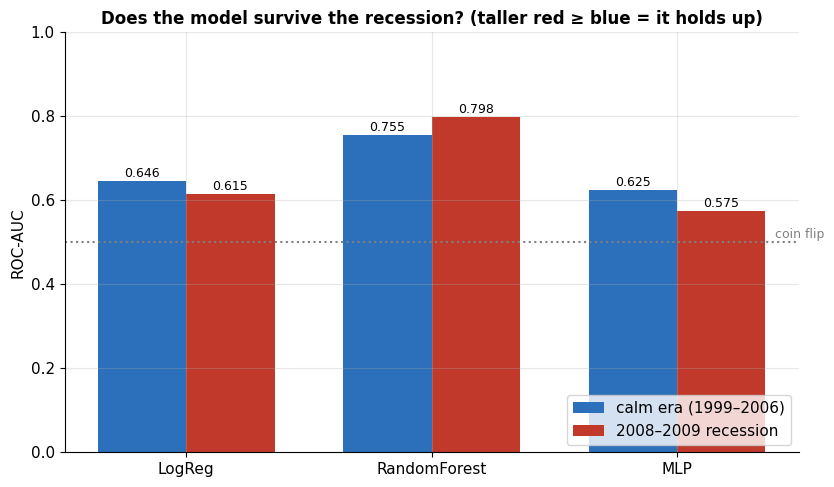

In [21]:
models=stress["model"].tolist(); x=np.arange(3); w=0.36
fig,ax=plt.subplots(figsize=(8.5,5))
b1=ax.bar(x-w/2,stress["calm_AUC"],w,label="calm era (1999–2006)",color="#2c6fbb")
b2=ax.bar(x+w/2,stress["recession_AUC"],w,label="2008–2009 recession",color="#c0392b")
for bars in (b1,b2):
    for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.01,f"{b.get_height():.3f}",ha="center",fontsize=9)
ax.axhline(0.5,ls=":",c="grey"); ax.text(2.4,0.51,"coin flip",color="grey",fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0,1.0); ax.set_ylabel("ROC-AUC")
ax.set_title("Does the model survive the recession? (taller red ≥ blue = it holds up)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.savefig("outputs/figures/stress_test.png",dpi=150); plt.show()

**The headline result.** The **random forest holds up** — its recession ROC-AUC is as high as (or higher than)
its calm-era score. A company about to fail in a crisis looks *as* recognisable as one failing in calm times —
arguably more so. The model **passes the stress test**. The simple linear model and the small neural network are
clearly **weaker** (closer to a coin flip), because the warning signs combine non-linearly and only the forest
captures that.

### A year-by-year view — and a trap to avoid

Let's score the calm-trained random forest on **every** year and watch how it does over time. The crisis is
shaded. This chart hides an important lesson — read the warning under it carefully.

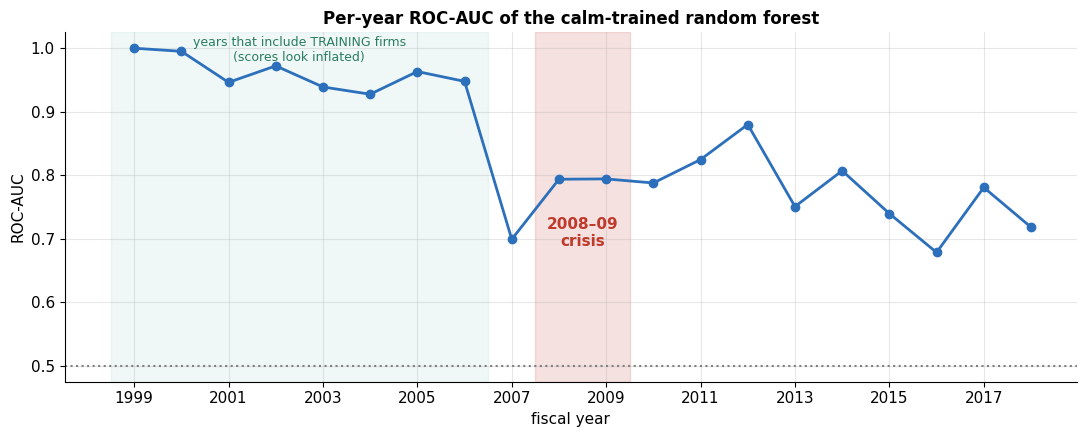

In [22]:
rf_full=fit_rf(Z(tr_idx),ytr)
yrs=[]; aucs=[]
for yr in range(1999,2019):
    idx=np.where((df["fyear"]==yr).values)[0]; yy=y[idx]
    if len(np.unique(yy))>1: yrs.append(yr); aucs.append(roc_auc_score(yy,proba(rf_full,idx)))
fig,ax=plt.subplots(figsize=(11,4.5))
ax.plot(yrs,aucs,marker="o",lw=2,color="#2c6fbb")
ax.axvspan(2007.5,2009.5,color="#c0392b",alpha=0.15); ax.text(2008.5,min(aucs)+0.01,"2008–09\ncrisis",ha="center",color="#c0392b",fontweight="bold")
ax.axvspan(1998.5,2006.5,color="#2a9d8f",alpha=0.07); ax.text(2002.5,max(aucs)-0.02,"years that include TRAINING firms\n(scores look inflated)",ha="center",color="#2a7d5f",fontsize=9)
ax.axhline(0.5,ls=":",c="grey")
ax.set_xlabel("fiscal year"); ax.set_ylabel("ROC-AUC"); ax.set_xticks(range(1999,2019,2))
ax.set_title("Per-year ROC-AUC of the calm-trained random forest")
plt.tight_layout(); plt.savefig("outputs/figures/per_year_auc.png",dpi=150); plt.show()
pd.DataFrame({"fyear":yrs,"ROC_AUC":np.round(aucs,4)}).to_csv("outputs/results/per_year_auc.csv",index=False)

> ⚠️ **Don't be fooled by this chart.** The pre-2007 points look sky-high — but those years still contain many
> of the **exact companies the model trained on**, so the model is partly *remembering* them, not predicting. The
> drop after 2006 looks like "the crisis broke the model," yet most of it is simply the model finally being
> tested on **firms it has never seen**. The fair, apples-to-apples comparison is the one we did just above —
> *held-out* calm firms (~0.76) vs *held-out* recession firms (~0.80) — and by that honest measure the model
> **does not break; it holds up.** This is the most important habit in machine learning: *make sure your test set
> is really unseen before you celebrate a number.*

## 📋 Discussion summary & limitations

In [23]:
print("="*64); print("SUMMARY — Calm era vs 2008–2009 recession (held-out firms)"); print("="*64)
display(stress.set_index("model")[["calm_AUC","recession_AUC","change"]].round(3))
print("\nBest model:", stress.loc[stress["recession_AUC"].idxmax(),"model"],
      "| recession ROC-AUC:", round(stress["recession_AUC"].max(),3))

SUMMARY — Calm era vs 2008–2009 recession (held-out firms)


,calm_AUC,recession_AUC,change
model,,,
LogReg,0.646,0.615,-0.031
RandomForest,0.755,0.798,0.042
MLP,0.625,0.575,-0.050



Best model: RandomForest | recession ROC-AUC: 0.798


### What we found
- **There is real, strong signal.** A random forest reaches ~**0.8 ROC-AUC** flagging companies about to fail —
  far above a coin flip and genuinely useful, unlike many "predict the market" tasks that are near-random.
- **The model survives the recession.** Its 2008–2009 score is as high as its calm-era score (sometimes higher).
  Financial distress looks the same — or sharper — in a crisis. The stress test is **passed**.
- **Model choice matters a lot.** The random forest clearly beats the logistic regression and the small neural
  network, because the warning signs interact non-linearly (low profit *and* high debt *and* weak liquidity).
- **The big lesson:** a great-looking per-year chart was an **illusion** caused by testing on companies the model
  had already seen. Only a properly *unseen* test set tells the truth.

### Honest limitations (important for any discussion section!)
- **Failure is rare**, so PR-AUC is low and recession scores rest on a few dozen failures — read them as
  *directional*, not precise.
- **The label is a simplification.** "Final reporting year = about to fail" is a reasonable proxy, but a company's
  last filing isn't always the year it legally goes bankrupt.
- **Companies repeat across years**, which is realistic (you re-score firms you already know) but means our
  "transfer" is across *time*, not to brand-new firms.
- **One dataset, one run, one seed.** A rigorous study repeats across seeds and model designs and reports the spread.
- **Survivorship & reporting biases** affect which firms appear at all.

### Where to go next
1. **Add macro context** (interest rates, GDP growth) so the model can *see* the regime, not just the firm.
2. **Predict 2-years-ahead** instead of the final year, and watch how much earlier warning costs in accuracy.
3. **Calibrate the threshold** for the recession's higher failure rate — ranking (AUC) can hold up even when the
   alarm level needs re-tuning.

> **Big takeaway for new ML practitioners:** a high score is only as trustworthy as the data behind it. Before you
> celebrate, always ask *"is my test set really like the world where this model will be used — and has the model
> truly never seen it?"* That single question separates a model that works in a notebook from one that works in a
> crisis. 💵